In [7]:
import pickle
import os
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

def load_binary_mask(filepath, threshold=1e-8):
    with open(filepath, "rb") as f:
        weight = pickle.load(f)
    return (np.abs(weight) > threshold).astype(int)  # 1 for kept, 0 for pruned

def jaccard_index(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union != 0 else 0.0

# Paths
wanda_dir = "./out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot/wanda_score/GSM8K_cot0shot_weight_only_disentangle"
direct_dir = "./out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_direct/wanda_score/GSM8K_direct_weight_only_disentangle"


# Categories to group by
categories = {
    "self_attn.q": "q_proj",
    "self_attn.k": "k_proj",
    "self_attn.v": "v_proj",
    "self_attn.o": "o_proj",
    "mlp.down": "down_proj",
    "mlp.gate": "gate_proj",
    "mlp.up": "up_proj"
}

# Collect data
jaccard_by_category = defaultdict(list)
common_files = sorted(set(os.listdir(wanda_dir)) & set(os.listdir(direct_dir)))

for filename in common_files:
    wanda_mask = load_binary_mask(os.path.join(wanda_dir, filename))
    direct_mask = load_binary_mask(os.path.join(direct_dir, filename))
    jaccard = jaccard_index(wanda_mask, direct_mask)

    for cat_key, cat_val in categories.items():
        if cat_val in filename:
            layer_match = re.search(r"layer_(\d+)", filename)
            layer = int(layer_match.group(1)) if layer_match else -1
            jaccard_by_category[cat_key].append((layer, jaccard))
            break

# Sort values
for cat in jaccard_by_category:
    jaccard_by_category[cat] = sorted(jaccard_by_category[cat], key=lambda x: x[0])

# Plot
plt.figure(figsize=(14, 10))
for i, (cat, values) in enumerate(jaccard_by_category.items(), 1):
    layers, jaccards = zip(*values)
    plt.subplot(3, 3, i)
    sns.lineplot(x=layers, y=jaccards, marker="o")
    plt.title(f"{cat} Jaccard Index")
    plt.xlabel("Layer")
    plt.ylabel("Jaccard")
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()


<Figure size 1400x1000 with 0 Axes>

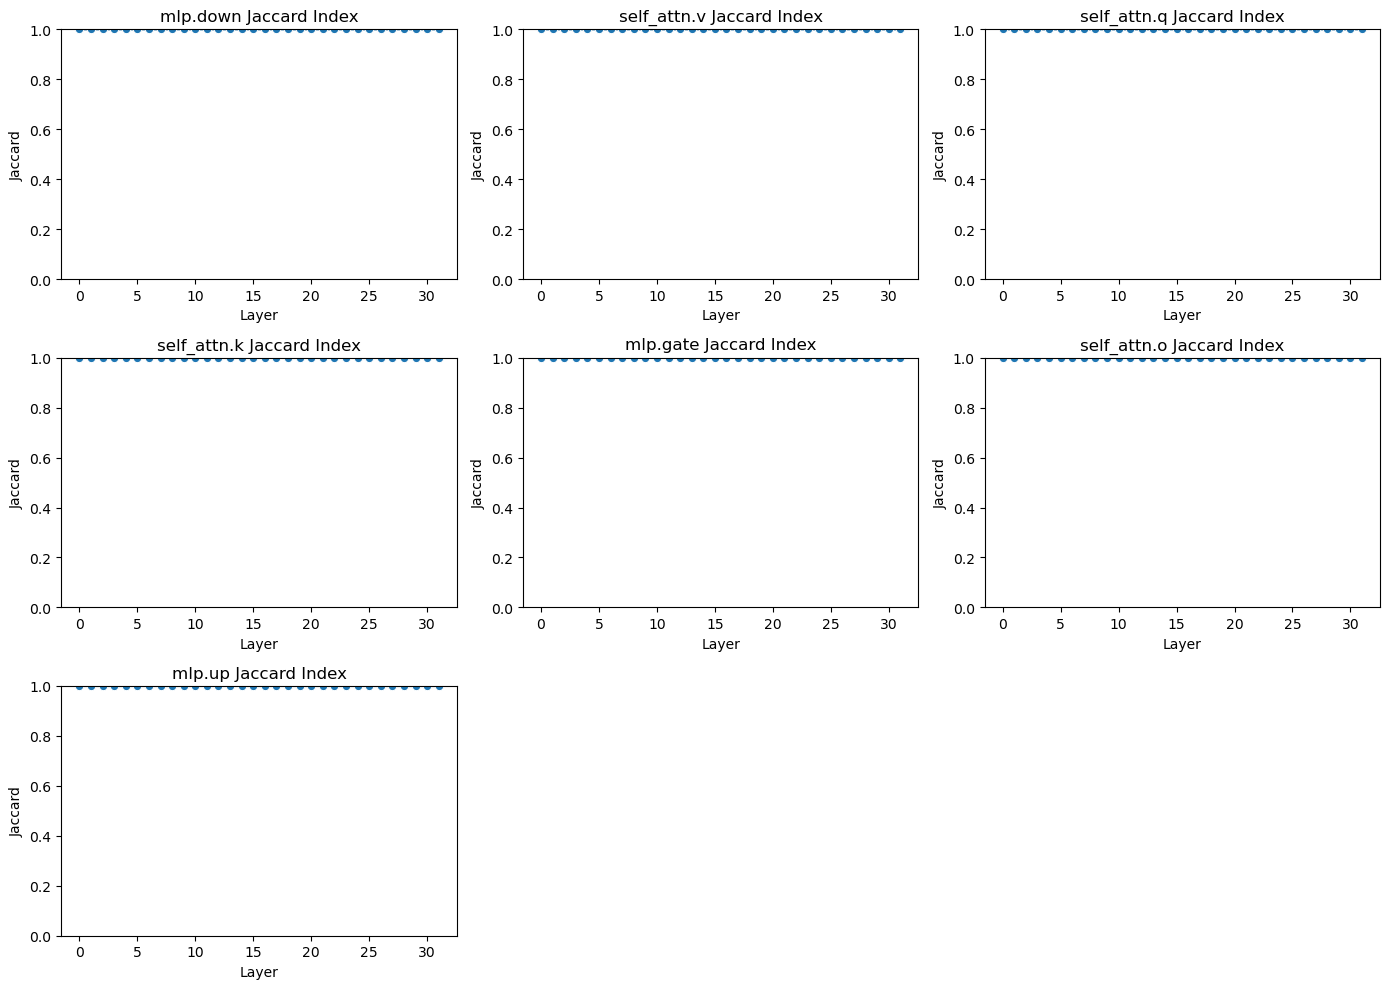

In [11]:
import os
import pickle
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Parameters
cot_dir = "./out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot/wanda_score/GSM8K_cot0shot_weight_only_disentangle"
direct_dir = "./out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_direct/wanda_score/GSM8K_direct_weight_only_disentangle"

cot_tag = "GSM8K_cot0shot"
direct_tag = "GSM8K_direct"

def load_binary_mask(filepath, threshold=1e-8):
    import torch
    with open(filepath, "rb") as f:
        data = pickle.load(f)

    if isinstance(data, dict):
        data = data["weight"] if "weight" in data else list(data.values())[0]

    if isinstance(data, torch.Tensor):
        data = data.detach().cpu().numpy()

    return (np.abs(data) > threshold).astype(int)

def jaccard_index(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union != 0 else 0.0

# Categories
categories = {
    "self_attn.q": "q_proj",
    "self_attn.k": "k_proj",
    "self_attn.v": "v_proj",
    "self_attn.o": "o_proj",
    "mlp.down": "down_proj",
    "mlp.gate": "gate_proj",
    "mlp.up": "up_proj"
}

jaccard_by_category = defaultdict(list)

cot_files = [f for f in os.listdir(cot_dir) if cot_tag in f]

for cot_file in cot_files:
    direct_file = cot_file.replace(cot_tag, direct_tag)
    cot_path = os.path.join(cot_dir, cot_file)
    direct_path = os.path.join(direct_dir, direct_file)

    if not os.path.exists(direct_path):
        continue  # skip if no matching file

    cot_mask = load_binary_mask(cot_path)
    direct_mask = load_binary_mask(direct_path)
    jaccard = jaccard_index(cot_mask, direct_mask)

    # Extract category and layer
    for cat_key, cat_val in categories.items():
        if cat_val in cot_file:
            match = re.search(r"layer_(\d+)", cot_file)
            layer = int(match.group(1)) if match else -1
            jaccard_by_category[cat_key].append((layer, jaccard))
            break

# Sort values per category
for cat in jaccard_by_category:
    jaccard_by_category[cat] = sorted(jaccard_by_category[cat], key=lambda x: x[0])

# Plot
plt.figure(figsize=(14, 10))
for i, (cat, values) in enumerate(jaccard_by_category.items(), 1):
    layers, jaccards = zip(*values)
    plt.subplot(3, 3, i)
    sns.lineplot(x=layers, y=jaccards, marker='o')
    plt.title(f"{cat} Jaccard Index")
    plt.xlabel("Layer")
    plt.ylabel("Jaccard")
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [4]:
os.listdir(wanda_dir)

['GSM8K_cot0shot_weight_only_disentangle']

In [12]:
import torch
import pickle
import numpy as np

def load_tensor(filepath):
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    if isinstance(data, dict):
        data = data["weight"] if "weight" in data else list(data.values())[0]
    return data.detach().cpu().numpy()

def get_topk_mask(tensor, topk_ratio=0.05):
    flat = np.abs(tensor.flatten())
    k = int(len(flat) * topk_ratio)
    if k == 0:
        raise ValueError("Tensor too small for top-k calculation.")
    threshold = np.partition(flat, -k)[-k]  # kth largest absolute value
    return (np.abs(tensor) >= threshold).astype(int)

def jaccard_index(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union != 0 else 0.0

# 文件路径
wanda_path = "/common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/scripts/out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot/wanda_score/GSM8K_cot0shot_weight_only_disentangle/W_metric_layer_0_name_mlp.down_proj_GSM8K_cot0shot_weight_only_disentangle.pkl"
direct_path = "/common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/scripts/out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_direct/wanda_score/GSM8K_direct_weight_only_disentangle/W_metric_layer_0_name_mlp.down_proj_GSM8K_direct_weight_only_disentangle.pkl"

# 加载权重
wanda_tensor = load_tensor(wanda_path)
direct_tensor = load_tensor(direct_path)

# 计算 Top 5% 的位置掩码
wanda_mask = get_topk_mask(wanda_tensor, topk_ratio=0.05)
direct_mask = get_topk_mask(direct_tensor, topk_ratio=0.05)

# 计算 Jaccard 指数
jaccard = jaccard_index(wanda_mask, direct_mask)
print("Top 5% Jaccard Index:", jaccard)


Top 5% Jaccard Index: 0.5049970827264024


In [ ]:
import os
import pickle
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# 设置路径
cot_dir = "./out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot/wanda_score/GSM8K_cot0shot_weight_only_disentangle"
direct_dir = "./out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_direct/wanda_score/GSM8K_direct_weight_only_disentangle"

wanda_tag = "GSM8K_cot0shot"
direct_tag = "GSM8K_direct"

# 分类对应关系
categories = {
    "self_attn.q": "q_proj",
    "self_attn.k": "k_proj",
    "self_attn.v": "v_proj",
    "self_attn.o": "o_proj",
    "mlp.down": "down_proj",
    "mlp.gate": "gate_proj",
    "mlp.up": "up_proj"
}

# 加载 tensor 并转换为 top-k 掩码
def load_tensor(filepath):
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    if isinstance(data, dict):
        data = data["weight"] if "weight" in data else list(data.values())[0]
    return data.detach().cpu().numpy()

def get_topk_mask(tensor, topk_ratio=0.05):
    flat = np.abs(tensor.flatten())
    k = int(len(flat) * topk_ratio)
    threshold = np.partition(flat, -k)[-k]
    return (np.abs(tensor) >= threshold).astype(int)

def jaccard_index(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union != 0 else 0.0

# 保存每类的 jaccard 指数结果
jaccard_by_category = defaultdict(list)

# 遍历 Wanda 文件
wanda_files = [f for f in os.listdir(wanda_dir) if wanda_tag in f]
for wanda_file in wanda_files:
    direct_file = wanda_file.replace(wanda_tag, direct_tag)
    wanda_path = os.path.join(wanda_dir, wanda_file)
    direct_path = os.path.join(direct_dir, direct_file)

    if not os.path.exists(direct_path):
        continue

    try:
        wanda_tensor = load_tensor(wanda_path)
        direct_tensor = load_tensor(direct_path)

        wanda_mask = get_topk_mask(wanda_tensor, topk_ratio=0.05)
        direct_mask = get_topk_mask(direct_tensor, topk_ratio=0.05)

        jaccard = jaccard_index(wanda_mask, direct_mask)

        # 分类模块 + 层号
        for cat_key, cat_val in categories.items():
            if cat_val in wanda_file:
                match = re.search(r"layer_(\d+)", wanda_file)
                layer = int(match.group(1)) if match else -1
                jaccard_by_category[cat_key].append((layer, jaccard))
                break
    except Exception as e:
        print(f"Skipping {wanda_file} due to error: {e}")

# sort and plot
plt.figure(figsize=(14, 10))
for i, (cat, values) in enumerate(jaccard_by_category.items(), 1):
    values = sorted(values, key=lambda x: x[0])
    layers, jaccards = zip(*values)
    plt.subplot(3, 3, i)
    sns.lineplot(x=layers, y=jaccards, marker='o')
    plt.title(f"{cat} (Top 5% Jaccard)")
    plt.xlabel("Layer")
    plt.ylabel("Jaccard")
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()
